<a href="https://colab.research.google.com/github/jovicma/euro2024-ace-lab-analysis/blob/main/notebooks/03_player_analysis_midfielders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install statsbombpy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsbombpy import sb
import warnings
warnings.filterwarnings('ignore')

print("Extraindo partidas, calculando minutagem e analisando meio-campistas (Isso levará 1-2 minutos)...")
df_matches = sb.matches(competition_id=55, season_id=282)

player_data = {}
player_minutes = {}

for idx, match in df_matches.iterrows():
    match_id = match['match_id']
    events = sb.events(match_id=match_id)
    max_min = events['minute'].max()

    # --- A. CÁLCULO DE MINUTOS JOGADOS NA PARTIDA ---
    subs = events[events['type'] == 'Substitution']
    subs_in = dict(zip(subs['substitution_replacement'], subs['minute']))
    subs_out = dict(zip(subs['player'], subs['minute']))

    # Identificar expulsões de forma segura (verificando se as colunas existem)
    has_foul_card = 'foul_committed_card' in events.columns
    has_bad_card = 'bad_behaviour_card' in events.columns

    is_foul_red = (events['foul_committed_card'] == 'Red Card') if has_foul_card else pd.Series(False, index=events.index)
    is_bad_red = (events['bad_behaviour_card'] == 'Red Card') if has_bad_card else pd.Series(False, index=events.index)

    reds = events[is_foul_red | is_bad_red]

    if len(reds) > 0:
        for p, min_red in zip(reds['player'], reds['minute']):
            subs_out[p] = min_red

    # Computar os minutos de todos os jogadores que registraram algum evento no jogo
    for player in events['player'].dropna().unique():
        start_min = subs_in.get(player, 0)
        end_min = subs_out.get(player, max_min)

        mins_played = end_min - start_min
        if mins_played > 0:
            player_minutes[player] = player_minutes.get(player, 0) + mins_played

    # --- B. EXTRAÇÃO DE MÉTRICAS DOS MEIO-CAMPISTAS ---
    if 'position' not in events.columns: continue
    events['position'] = events['position'].fillna('Unknown')
    mids = events[events['position'].str.contains('Midfield')].copy()

    # 1. Passes Progressivos (Avanço >= 15 unidades E início fora do 1º terço)
    passes = mids[(mids['type'] == 'Pass') & (mids['pass_outcome'].isnull())].copy()
    if 'location' in passes.columns and 'pass_end_location' in passes.columns:
        passes['x_start'] = passes['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else 0)
        passes['x_end'] = passes['pass_end_location'].apply(lambda loc: loc[0] if isinstance(loc, list) else 0)

        # Filtro atualizado: Início no terço médio/final (x >= 40) e avanço de 15 unidades
        prog_passes = passes[(passes['x_end'] - passes['x_start'] >= 15) & (passes['x_start'] >= 40)]

        for player, group in prog_passes.groupby('player'):
            if player not in player_data:
                player_data[player] = {'prog_passes': 0, 'def_actions': 0, 'team': group['team'].iloc[0]}
            player_data[player]['prog_passes'] += len(group)

    # 2. Ações Defensivas
    is_interception = mids['type'].isin(['Interception', 'Ball Recovery'])
    is_tackle = (mids['type'] == 'Duel') & (mids.get('duel_type') == 'Tackle')
    def_events = mids[is_interception | is_tackle]

    for player, group in def_events.groupby('player'):
        if player not in player_data:
            player_data[player] = {'prog_passes': 0, 'def_actions': 0, 'team': group['team'].iloc[0]}
        player_data[player]['def_actions'] += len(group)

# --- C. TRANSFORMAÇÃO E NORMALIZAÇÃO ---
df_mids = pd.DataFrame.from_dict(player_data, orient='index').reset_index()
df_mids = df_mids.rename(columns={'index': 'player'})

# Trazer os minutos calculados para o DataFrame
df_mids['minutes'] = df_mids['player'].map(player_minutes).fillna(0)

# Filtro restrito: Pelo menos 180 minutos jogados
df_mids = df_mids[df_mids['minutes'] >= 180].copy()

# Normalização por 90 minutos
df_mids['prog_passes_p90'] = (df_mids['prog_passes'] / df_mids['minutes']) * 90
df_mids['def_actions_p90'] = (df_mids['def_actions'] / df_mids['minutes']) * 90

print("\nBase normalizada por 90 minutos (Filtro >= 180 mins):")
display(df_mids.sort_values(by='prog_passes_p90', ascending=False).head(10))

Extraindo partidas, calculando minutagem e analisando meio-campistas (Isso levará 1-2 minutos)...

Base normalizada por 90 minutos (Filtro >= 180 mins):


,player,prog_passes,def_actions,team,minutes,prog_passes_p90,def_actions_p90
56,Toni Kroos,54,27,Germany,488,9.959016,4.979508
144,Jorge Luiz Frello Filho,23,11,Italy,220,9.409091,4.500000
17,Aurélien Djani Tchouaméni,51,22,France,490,9.367347,4.040816
30,Bruno Miguel Borges Fernandes,37,22,Portugal,387,8.604651,5.116279
48,Granit Xhaka,40,34,Switzerland,504,7.142857,6.071429
148,Luka Modrić,19,26,Croatia,242,7.066116,9.669421
63,Kevin De Bruyne,29,21,Belgium,379,6.886544,4.986807
39,Florian Grillitsch,15,17,Austria,198,6.818182,7.727273
35,Vitor Machado Ferreira,26,37,Portugal,357,6.554622,9.327731
64,Mykola Shaparenko,16,10,Ukraine,222,6.486486,4.054054


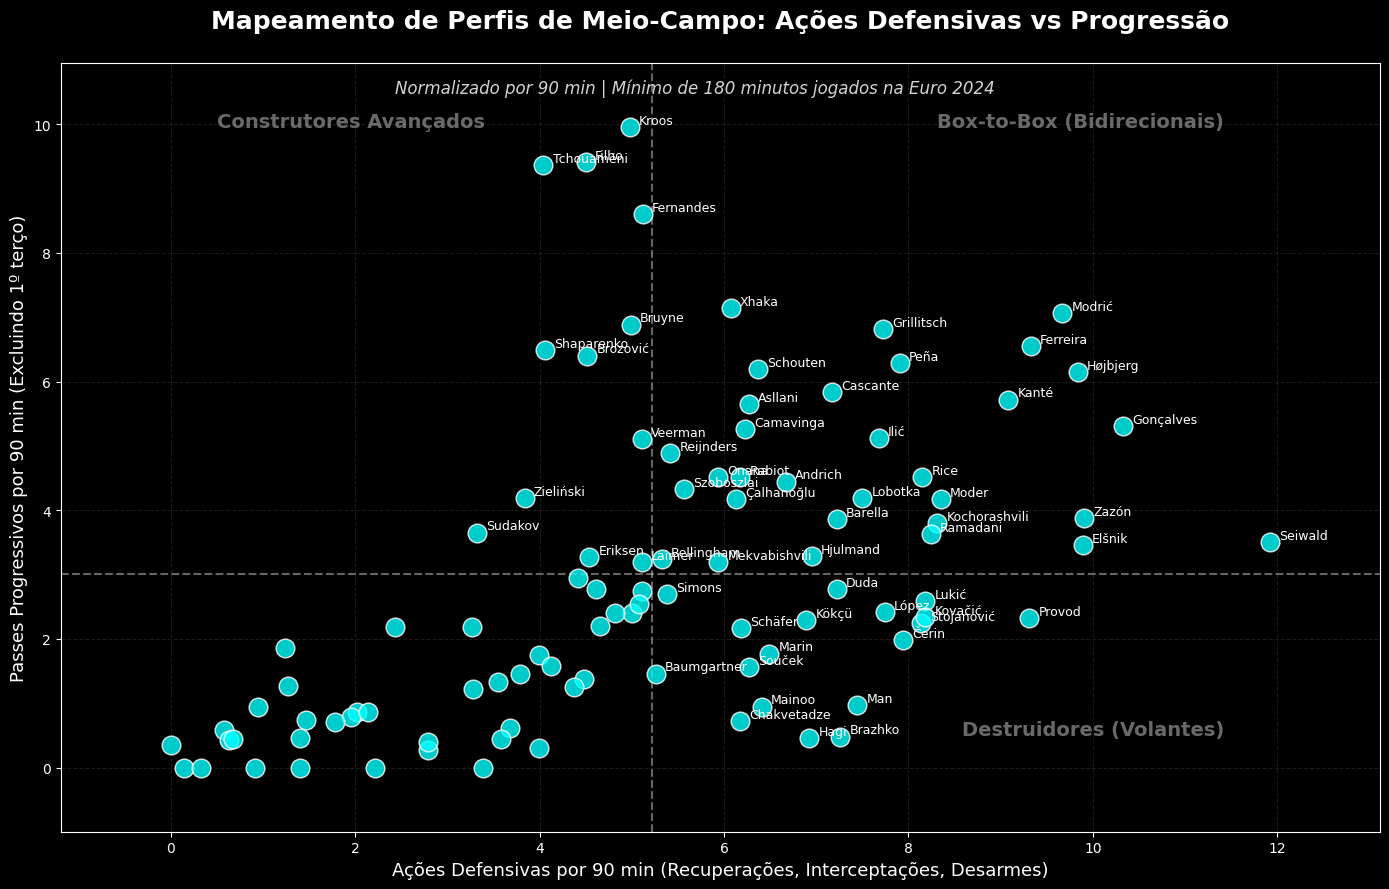

In [4]:
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(14, 9))

# Plot principal
sns.scatterplot(
    data=df_mids,
    x="def_actions_p90",
    y="prog_passes_p90",
    color="cyan",
    edgecolor="white",
    s=180,
    alpha=0.8,
    ax=ax,
    zorder=3
)

# Linhas de médias
media_def_p90 = df_mids['def_actions_p90'].mean()
media_prog_p90 = df_mids['prog_passes_p90'].mean()

ax.axvline(media_def_p90, linestyle="--", color="white", alpha=0.4, linewidth=1.5)
ax.axhline(media_prog_p90, linestyle="--", color="white", alpha=0.4, linewidth=1.5)

# Nomes dos jogadores acima da média em pelo menos uma métrica (Todos em branco agora)
elite_mids = df_mids[(df_mids['def_actions_p90'] > media_def_p90) | (df_mids['prog_passes_p90'] > media_prog_p90)]

for i, row in elite_mids.iterrows():
    nome_curto = row['player'].split()[-1]
    ax.text(row['def_actions_p90'] + 0.1, row['prog_passes_p90'] + 0.05, nome_curto, fontsize=9, color='white')

# Rótulos dos Quadrantes (Padronizados)
ax.text(df_mids['def_actions_p90'].max() - 0.5, df_mids['prog_passes_p90'].max(), 'Box-to-Box (Bidirecionais)', color='lightgrey', alpha=0.5, fontsize=14, fontweight='bold', ha='right')
ax.text(df_mids['def_actions_p90'].min() + 0.5, df_mids['prog_passes_p90'].max(), 'Construtores Avançados', color='lightgrey', alpha=0.5, fontsize=14, fontweight='bold', ha='left')
ax.text(df_mids['def_actions_p90'].max() - 0.5, df_mids['prog_passes_p90'].min() + 0.5, 'Destruidores (Volantes)', color='lightgrey', alpha=0.5, fontsize=14, fontweight='bold', ha='right')

# Títulos e Estética
ax.set_title("Mapeamento de Perfis de Meio-Campo: Ações Defensivas vs Progressão", fontsize=18, fontweight="bold", pad=25, color="white")
fig.text(0.5, 0.89, 'Normalizado por 90 min | Mínimo de 180 minutos jogados na Euro 2024', ha='center', fontsize=12, color='lightgrey', style='italic')

ax.set_xlabel("Ações Defensivas por 90 min (Recuperações, Interceptações, Desarmes)", fontsize=13, color="white")
ax.set_ylabel("Passes Progressivos por 90 min (Excluindo 1º terço)", fontsize=13, color="white")

plt.grid(True, linestyle="--", alpha=0.1)
plt.margins(0.1)
plt.tight_layout()
plt.savefig("midfielder_profiles_p90.png", dpi=300)
plt.show()